# Exploratory Data Analysis (EDA) per Outlet
Analisis awal data ulasan, rating, dan sentimen untuk setiap cabang Kopi Kenangan.

In [4]:
# Setup environment jika dijalankan di Google Colab / Kaggle
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = 'kaggle_secrets' in sys.modules

if IN_COLAB:
    print("Colab detected. Pastikan file 'cleaned_reviews.csv' sudah diupload.")
elif IN_KAGGLE:
    print("Kaggle detected. Sesuaikan input path dataset.")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="whitegrid")

## 1. Load Data

In [6]:
# Cari path lokal atau fallback ke Colab/Kaggle
dataset_path = '../preprocessing/cleaned_reviews.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'cleaned_reviews.csv'

df = pd.read_csv(dataset_path)
df = df.dropna(subset=['text_clean'])
print(f"Total data: {len(df)} baris")
df.head()

Total data: 2926 baris


,nama_pengulas,ulasan,rating,nama_gerai,text_clean,word_count,sentiment
0,Immia,"Sekarang udah jadi Kenangan boulangerie, semak...",5 bintang,Kopi Kenangan - Kota Kasablanka,kenang boulangerie keren tempat pilih roti mes...,17,positive
1,Anton Kristanto,Outlet kopi kenangan versi premium... The best...,5 bintang,Kopi Kenangan - Kota Kasablanka,outlet kopi kenang versi premium best banget l...,11,positive
2,Delverland,kalo makan siang sering beli kopken walaupun a...,5 bintang,Kopi Kenangan - Kota Kasablanka,makan siang beli kopken antri banget layan tet...,13,positive
3,Christian S,Semuanya pasti udh pd tau sm KopKen kan..\nUtk...,5 bintang,Kopi Kenangan - Kota Kasablanka,udh sm kopken kan tempat baguscozy mirip kafe ...,21,positive
4,Jade Ayu,Pilihan kopi yg menyenangkan dengan harga stan...,4 bintang,Kopi Kenangan - Kota Kasablanka,pilih kopi senang harga standar mall milik ger...,19,positive


## 2. Preprocessing Kolom Rating

In [7]:
# Konversi string rating ke numerik
df['rating_num'] = df['rating'].str.extract('(\d+)').astype(float)
print(f"Jumlah outlet: {df['nama_gerai'].nunique()}")

Jumlah outlet: 24


## 3. Agregasi Data per Outlet

In [8]:
# Grouping statistik per gerai
summary_per_gerai = df.groupby('nama_gerai').agg(
    total_review=('ulasan', 'count'),
    avg_rating=('rating_num', 'mean'),
    avg_word_count=('word_count', 'mean')
).reset_index()

# Hitung distribusi sentimen
sentiment_dist = pd.crosstab(df['nama_gerai'], df['sentiment'], normalize='index') * 100
sentiment_dist = sentiment_dist.rename(columns={
    'negative': 'pct_negative',
    'neutral': 'pct_neutral',
    'positive': 'pct_positive'
}).reset_index()

gerai_stats = pd.merge(summary_per_gerai, sentiment_dist, on='nama_gerai')

# Filter/flag outlet dengan review < 20 (low confidence)
gerai_stats['confidence_level'] = gerai_stats['total_review'].apply(lambda x: 'High' if x >= 20 else 'Low')
gerai_stats = gerai_stats.sort_values(by='total_review', ascending=False)
gerai_stats

,nama_gerai,total_review,avg_rating,avg_word_count,pct_negative,pct_neutral,pct_positive,confidence_level
0,Kopi Kenangan - Kota Kasablanka,257,4.140078,9.443580,15.175097,5.836576,78.988327,High
6,KopiKenangan-RCVeteran(DriveThru),250,3.928000,9.200000,20.800000,7.200000,72.000000,High
2,KopiKenangan-CentralPark2,205,4.073171,8.521951,17.073171,4.390244,78.536585,High
13,KopiKenangan-RukoJoglo,187,4.165775,9.454545,17.112299,4.812834,78.074866,High
8,KopiKenangan-RawaBelongJakarta,153,4.052288,10.973856,20.915033,5.882353,73.202614,High
18,KopiKenangan-RukoPuriBeta,142,4.197183,8.802817,16.901408,4.225352,78.873239,High
23,KopiKenangan-UrbanHubPalmerah,138,4.246377,10.101449,15.942029,4.347826,79.710145,High
1,KopiKenangan-BlokMPlaza(LG),135,4.192593,11.066667,17.777778,3.703704,78.518519,High
5,KopiKenangan-PosPengumbenJakartaBarat,131,4.389313,10.496183,12.977099,3.816794,83.206107,High
9,KopiKenangan-RukoBendunganHilir(FCK),125,3.880000,11.432000,25.600000,5.600000,68.800000,High


## 4. Visualisasi

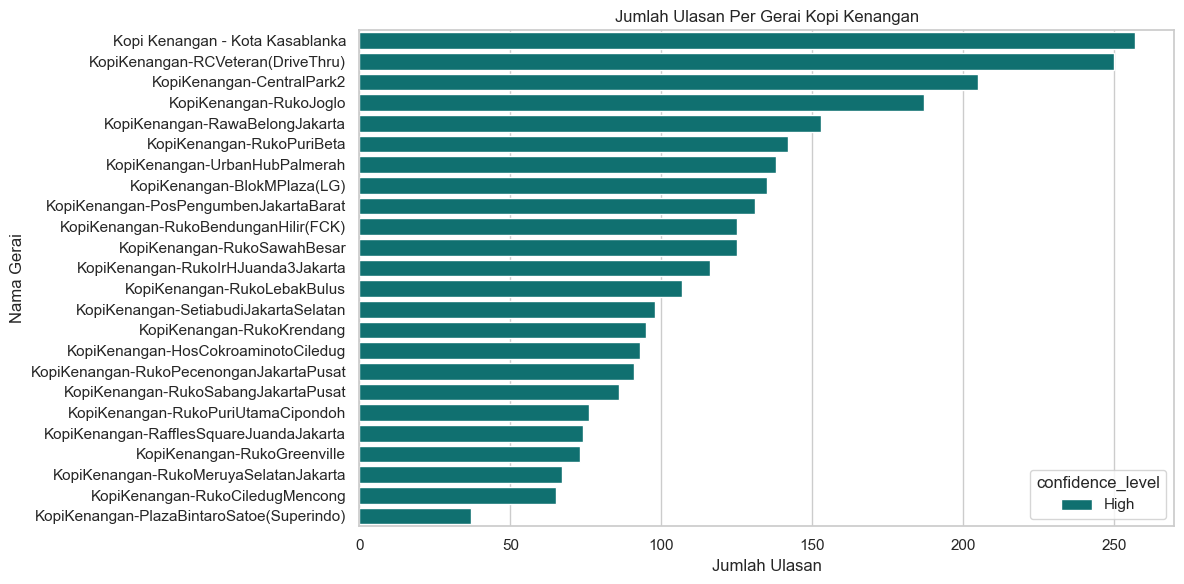

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=gerai_stats, y='nama_gerai', x='total_review', hue='confidence_level', palette={'High': 'teal', 'Low': 'salmon'})
plt.title('Jumlah Ulasan Per Gerai Kopi Kenangan')
plt.xlabel('Jumlah Ulasan')
plt.ylabel('Nama Gerai')
plt.tight_layout()
plt.show()

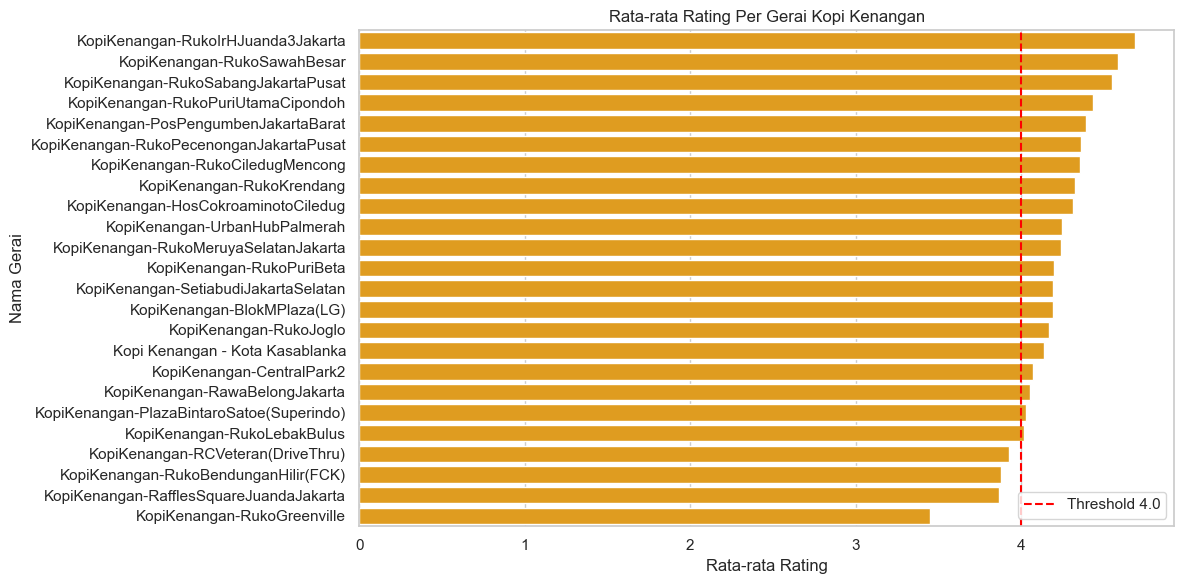

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=gerai_stats.sort_values(by='avg_rating', ascending=False), y='nama_gerai', x='avg_rating', color='orange')
plt.axvline(x=4.0, color='red', linestyle='--', label='Threshold 4.0')
plt.title('Rata-rata Rating Per Gerai Kopi Kenangan')
plt.xlabel('Rata-rata Rating')
plt.ylabel('Nama Gerai')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Simpan Hasil Analisis

In [11]:
os.makedirs('../reports', exist_ok=True)

report_dict = {
    "total_reviews_all_outlets": int(len(df)),
    "total_outlets": int(df['nama_gerai'].nunique()),
    "outlets_stats": gerai_stats.to_dict(orient='records'),
    "low_confidence_outlets": gerai_stats[gerai_stats['confidence_level'] == 'Low']['nama_gerai'].tolist()
}

with open('../reports/eda_per_gerai_summary.json', 'w') as f:
    json.dump(report_dict, f, indent=4)

print("Laporan berhasil disimpan di modeling/reports/")

Laporan berhasil disimpan di modeling/reports/
